# LAB 5

- Alunos:
    - Orlando Virginio Penha Junior
    - Bruno Osorio de Carvalho Almeida
    - Vinícius Ian Alves Lopes
    - Jhonata Pereira de Andrade

## Imports

In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Leitura dos Dados

In [2]:
df_attorneys = load_dataset("jamiequint/sf_criminal_court", "attorneys")["train"].to_pandas()
# df_calendar = load_dataset("jamiequint/sf_criminal_court", "calendar")["train"].to_pandas()
df_calendar_jud = load_dataset("jamiequint/sf_criminal_court", "calendar_with_judicial_assignments")["train"].to_pandas()
df_cases = load_dataset("jamiequint/sf_criminal_court", "cases")["train"].to_pandas()
df_da_arrests = load_dataset("jamiequint/sf_criminal_court", "da_arrests")["train"].to_pandas()
df_da_prosecuted = load_dataset("jamiequint/sf_criminal_court", "da_prosecuted")["train"].to_pandas()
# df_jud_assig_src = load_dataset("jamiequint/sf_criminal_court", "judicial_assignment_sources")["train"].to_pandas()
# df_jud_assig = load_dataset("jamiequint/sf_criminal_court", "judicial_assignments")["train"].to_pandas()
# df_jud_dept_assig = load_dataset("jamiequint/sf_criminal_court", "judicial_department_assignments")["train"].to_pandas()
# df_jud_officers = load_dataset("jamiequint/sf_criminal_court", "judicial_officers")["train"].to_pandas()
df_register = load_dataset("jamiequint/sf_criminal_court", "register_of_actions")["train"].to_pandas()
# df_case_matches = load_dataset("jamiequint/sf_criminal_court", "sfsc_case_matches")["train"].to_pandas()
df_charge_disp = load_dataset("jamiequint/sf_criminal_court", "sfsc_charge_dispositions")["train"].to_pandas()

## Perguntas para direcionar a análise do Dataset
- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?
- 2- Qual a duração média dos processos ? E processos com mais advogados tendem a ter mais movimentações ?
- 3- Os casos que nunca foram encerrados ou duraram mais de 1 ano são do mesmo juiz? Os crimes desses casos são semelhantes ou os advogados associados são os mesmos?
- 4- Quais os tipos de defensores mais atuantes na corte, publicos ou privados? Qual tipo consegue ser mais eficiente? (Resultado diferente de culpado)
- 5- Existe algum padrão de aumento ou queda no número de processos criminais dependendo do mês do ano?

## Pergunta 1

- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?

A resposta dessa pergunta está relacionada com as tabelas de **df_da_arests** e **df_da_prosecuted**

### Análise Exploratória de Dados

In [3]:
df_da_arrests.info()

<class 'pandas.DataFrame'>
RangeIndex: 176130 entries, 0 to 176129
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   incident_number         176130 non-null  str  
 1   court_number            176130 non-null  str  
 2   arrest_date             176130 non-null  str  
 3   arresting_agency        176130 non-null  str  
 4   crime_type              176130 non-null  str  
 5   list_of_booked_charges  176130 non-null  str  
 6   booked_case_type        176130 non-null  str  
 7   dv_case                 176130 non-null  str  
 8   da_action_taken         176130 non-null  str  
 9   data_as_of              176130 non-null  str  
 10  data_loaded_at          176130 non-null  str  
dtypes: str(11)
memory usage: 38.3 MB


In [4]:
df_da_prosecuted.info()

<class 'pandas.DataFrame'>
RangeIndex: 120827 entries, 0 to 120826
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   incident_number        120827 non-null  str  
 1   court_number           120827 non-null  str  
 2   arrest_date            120827 non-null  str  
 3   list_of_filed_charges  120827 non-null  str  
 4   filed_case_type        120827 non-null  str  
 5   crime_type             120827 non-null  str  
 6   dv_case                120827 non-null  str  
 7   da_action_taken        120827 non-null  str  
 8   case_status            120827 non-null  str  
 9   data_as_of             120827 non-null  str  
 10  data_loaded_at         120827 non-null  str  
dtypes: str(11)
memory usage: 30.1 MB


In [5]:
df_da_arrests.head()

,incident_number,court_number,arrest_date,arresting_agency,crime_type,list_of_booked_charges,booked_case_type,dv_case,da_action_taken,data_as_of,data_loaded_at
0,140193864,14006811,2014-03-06T00:00:00.000,BART,Narcotics,"11350A,640C1",Felony,No,Further Investigation Requested,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
1,140183956,14006463,2014-03-03T00:00:00.000,SFPD,Narcotics,"11351,11364.1A,21955",Felony,No,Discharged,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
2,140272242,14009242,2014-04-01T00:00:00.000,SFPD,Narcotics,11352A,Felony,No,MTR/Referred to Other Agency,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
3,140299876,14010079,2014-04-10T00:00:00.000,SFPD,Narcotics,"182A1,11352A,11351",Felony,No,MTR/Referred to Other Agency,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
4,Z20140423-14011228,14011228,2014-04-23T00:00:00.000,SFSU,Narcotics,"148A1,11357A,11350A",Felony,No,Discharged,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280


In [6]:
df_da_prosecuted.head()

,incident_number,court_number,arrest_date,list_of_filed_charges,filed_case_type,crime_type,dv_case,da_action_taken,case_status,data_as_of,data_loaded_at
0,Z20160508-16008776,16008776,2016-05-08T00:00:00.000,"23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
1,160390313,2495093,2016-05-13T00:00:00.000,"20002A/M/0, 23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
2,Z20160517-16009375,16009375,2016-05-17T00:00:00.000,"23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
3,Z20160516-16009292,16009292,2016-05-16T00:00:00.000,"23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4,160357266,16008334,2016-05-01T00:00:00.000,"23152B/M/0, 23152A/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


<Axes: ylabel='booked_case_type'>

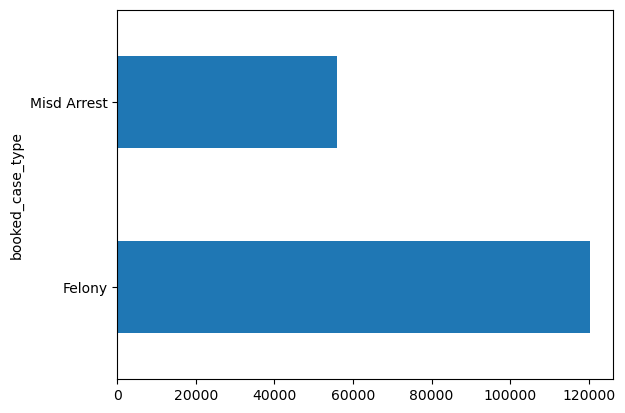

In [7]:
df_da_arrests.value_counts('booked_case_type').plot.barh()

<Axes: ylabel='filed_case_type'>

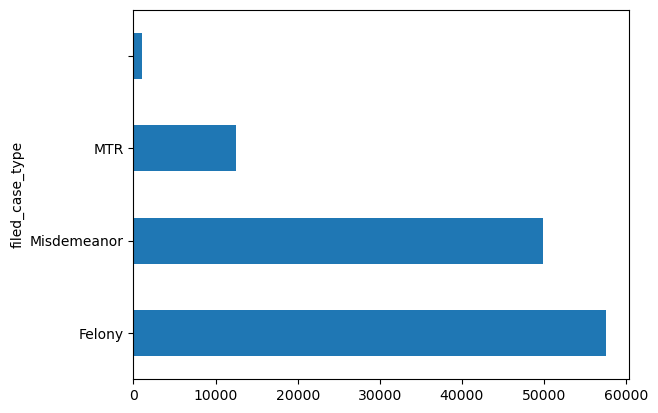

In [8]:
df_da_prosecuted.value_counts('filed_case_type').plot.barh()

Aqui notamos o valor de MTR, que significa Motion to Revoke ("Pedido de Revogação"), também notamos que há valores nulos nesse campo filed_case_type.

In [9]:
df_da_prosecuted['filed_case_type'].unique()

<ArrowStringArray>
['Misdemeanor', 'Felony', '', 'MTR']
Length: 4, dtype: str

In [10]:
df_da_arrests['booked_case_type'].isna().sum()

np.int64(0)

#### Investigando os Dados nulos de df_da_prosecuted

Durante a análise exploratória, identificou-se que o campo filed_case_type do dataframe df_da_prosecuted apresentava valores ausentes (vazios) referentes à gravidade dos casos, devido a inconsistências no preenchimento original. Para mitigar a perda de dados, realizou-se a imputação de parte desses registros utilizando expressões regulares (Regex) para extrair as tipificações ('M' ou 'F') embutidas na coluna list_of_filed_charges. Os registros que ainda assim permaneceram nulos (NaN), por completa falta de informação em ambas as colunas, foram removidos do dataset para garantir a integridade da análise final.

In [11]:
df_da_prosecuted[df_da_prosecuted['filed_case_type'] == '']

,incident_number,court_number,arrest_date,list_of_filed_charges,filed_case_type,crime_type,dv_case,da_action_taken,case_status,data_as_of,data_loaded_at
329,Z20190502-19006844,19006844,2019-05-02T00:00:00.000,"23152A/M/0, 23152B/M/0, 23103/NA/0",,DUI,No,New charges filed,Record Sealed,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
386,190772612,19016197,2019-10-13T00:00:00.000,"23152A/M/0, 11350A/M/0, 14601.2A/M/0, V22514/N...",,DUI,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
563,Z20210601-21005373,21005373,2021-06-01T00:00:00.000,"23152A/M/0, 23152B/M/0, 23103/NA/0",,DUI,No,Other DA Office Action,Pled Guilty to Other Case or Other DA Action,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
590,Z20210930-02527988,2527988,2021-09-24T00:00:00.000,"23152A/M/0, 23103/NA/0, 23152B/M/0",,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
592,Z20210913-02527704,2527704,2021-09-03T00:00:00.000,"23152A/M/0, 23152B/M/0, 12500A/M/0, 5000103/NA/0",,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
...,...,...,...,...,...,...,...,...,...,...,...
113368,230460424,23009968,2023-07-03T00:00:00.000,"25850A/M/0, 417C/NA/0",,Weapons,No,New charges filed,Successful Diversion,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
113531,250550895,25021219,2025-09-30T00:00:00.000,"21310/M/0, 5000615/NA/0",,Weapons,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
113931,122381701,2530916,2022-05-30T00:00:00.000,286.5A/NA/0,,Other,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
116640,120242588,2468783,2012-07-24T00:00:00.000,"5000103/NA/0, 23152A/M/0, 22107/I/0, 11550A/M/0",,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


In [12]:
letras_extraidas = df_da_prosecuted['list_of_filed_charges'].str.extract(r'/([MF])/')[0]

dicionario_traducao = {
    'M': 'Misdemeanor',
    'F': 'Felony'
}

valores_corrigidos = letras_extraidas.map(dicionario_traducao)
linhas_vazias = df_da_prosecuted['filed_case_type'] == ''

df_da_prosecuted.loc[linhas_vazias, 'filed_case_type'] = valores_corrigidos[linhas_vazias]

In [13]:
df_da_prosecuted['filed_case_type'].isna().sum()

np.int64(931)

In [14]:
df_da_prosecuted[df_da_prosecuted['filed_case_type'].isna()]

,incident_number,court_number,arrest_date,list_of_filed_charges,filed_case_type,crime_type,dv_case,da_action_taken,case_status,data_as_of,data_loaded_at
4750,110072129,11002438,2011-01-24T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4751,Z20110206-11003815,11003815,2011-02-05T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4752,110283213,11009571,2011-04-07T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4759,120030167,12001093,2012-01-11T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4762,120277585,12009327,2012-04-07T00:00:00.000,,NaN,,No,New charges filed,Pled Guilty to Other Case or Other DA Action,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
...,...,...,...,...,...,...,...,...,...,...,...
34807,260126000,26005119,2026-03-05T00:00:00.000,,NaN,,No,New charges filed,Pending,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
34810,260181048,26007364,2026-04-01T00:00:00.000,,NaN,,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
81706,Z20220615-02530813,2530813,2022-06-15T00:00:00.000,666.5A/NA/0,NaN,Motor Vehicle Theft,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
99429,190790893,19017430,2019-05-12T00:00:00.000,4573.8/NA/0,NaN,Other,No,New charges filed,Pending,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


In [15]:
df_da_prosecuted = df_da_prosecuted.dropna(subset=['filed_case_type'])

In [16]:
df_da_prosecuted['filed_case_type'].isna().sum()

np.int64(0)

In [17]:
df_da_prosecuted['filed_case_type'].value_counts()

filed_case_type
Felony         57512
Misdemeanor    49906
MTR            12478
Name: count, dtype: int64

### Merge das Tabelas para responder a pergunta

In [18]:
df_pergunta1 = pd.merge(df_da_arrests,df_da_prosecuted,how='inner',on='incident_number')

In [19]:
df_pergunta1.info()

<class 'pandas.DataFrame'>
RangeIndex: 123412 entries, 0 to 123411
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   incident_number         123412 non-null  str  
 1   court_number_x          123412 non-null  str  
 2   arrest_date_x           123412 non-null  str  
 3   arresting_agency        123412 non-null  str  
 4   crime_type_x            123412 non-null  str  
 5   list_of_booked_charges  123412 non-null  str  
 6   booked_case_type        123412 non-null  str  
 7   dv_case_x               123412 non-null  str  
 8   da_action_taken_x       123412 non-null  str  
 9   data_as_of_x            123412 non-null  str  
 10  data_loaded_at_x        123412 non-null  str  
 11  court_number_y          123412 non-null  str  
 12  arrest_date_y           123412 non-null  str  
 13  list_of_filed_charges   123412 non-null  str  
 14  filed_case_type         123412 non-null  str  
 15  crime_type_

In [20]:
len(df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')])

13519

O cálculo acima demonstra que houve 13.519 incidentes em que a autoridade policial registrou a prisão como um crime grave (Felony), mas a promotoria decidiu rebaixar a tipificação e formalizar a acusação apenas como um delito menor (Misdemeanor).

In [21]:
len(df_pergunta1[df_pergunta1['booked_case_type'] == 'Felony'])

98207

In [22]:
casos_reducao = len(df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')])
total_felony = len(df_pergunta1[df_pergunta1['booked_case_type'] == 'Felony'])

print(f'Percentual: {casos_reducao/total_felony * 100:.2f}%')

Percentual: 13.77%


A análise dos dados revela que, de um total de 98.207 prisões tipificadas preliminarmente como crimes graves, 13.519 sofreram desclassificação por parte da promotoria. Isso representa uma taxa de redução de 13,77%, evidenciando que uma parcela significativa dos casos perde força de acusação na transição entre a delegacia e o tribunal.

In [23]:
df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')]

,incident_number,court_number_x,arrest_date_x,arresting_agency,crime_type_x,list_of_booked_charges,booked_case_type,dv_case_x,da_action_taken_x,data_as_of_x,...,court_number_y,arrest_date_y,list_of_filed_charges,filed_case_type,crime_type_y,dv_case_y,da_action_taken_y,case_status,data_as_of_y,data_loaded_at_y
5,170185762,17003403,2017-03-06T00:00:00.000,SFPD,Narcotics,"11352A,11353.6B,135",Felony,No,Discharged,2026-04-27T00:00:00.000,...,17003374,2017-03-06T00:00:00.000,11350A/M/0,Misdemeanor,Narcotics,No,New charges filed,Successful Diversion,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
7,180235959,18004973,2018-03-30T00:00:00.000,SFPD,Narcotics,"11351,11378,113623A4,166A4",Felony,No,Discharged,2026-04-27T00:00:00.000,...,18004971,2018-03-30T00:00:00.000,12500A/M/0,Misdemeanor,Selected Traffic,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
10,190634391,19013481,2019-08-27T00:00:00.000,SFPD,Narcotics,"11351,11378,11351.5,11352A,11379A,4000A1,182A1...",Felony,No,Discharged,2026-04-27T00:00:00.000,...,19013479,2019-08-27T00:00:00.000,11350A/M/0,Misdemeanor,Narcotics,No,New charges filed,Pled Guilty to Other Case or Other DA Action,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
18,230890144,23020874,2023-12-21T00:00:00.000,SFPD,Narcotics,"11351.5,11375B1,182A1,33,11350A",Felony,No,Discharged,2026-04-27T00:00:00.000,...,23020873,2023-12-21T00:00:00.000,"23103A/M/0, 11350A/M/0, 11350A/M/0, 2800.1A/M/...",Misdemeanor,Selected Traffic,No,New charges filed,Fugitive Status,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
85,110119646,11004159,2011-02-08T00:00:00.000,SFPD,Narcotics,"11350A,11364A",Felony,No,Charges Filed,2026-04-27T00:00:00.000,...,11004159,2011-02-08T00:00:00.000,11350A/M/0,Misdemeanor,Narcotics,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123376,130665334,13022554,2013-08-12T00:00:00.000,SFPD,Narcotics,11350A,Felony,No,MTR/Referred to Other Agency,2026-04-27T00:00:00.000,...,13022552,2013-08-11T00:00:00.000,243.3/M/0,Misdemeanor,Assault and Battery,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
123382,130733016,13024765,2013-09-02T00:00:00.000,BART,Narcotics,"11350A,11364.1A",Felony,No,Discharged,2026-04-27T00:00:00.000,...,13024771,2013-09-02T00:00:00.000,"487A/M/0, 496A/M/0",Misdemeanor,Petty Theft,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
123391,130890440,13029872,2013-10-20T00:00:00.000,SFPD,Narcotics,"11350A,4060,148A1",Felony,No,Discharged,2026-04-27T00:00:00.000,...,13029867,2013-10-20T00:00:00.000,245A4/M/0,Misdemeanor,Assault and Battery,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
123392,130890440,13029872,2013-10-20T00:00:00.000,SFPD,Narcotics,"11350A,4060,148A1",Felony,No,Discharged,2026-04-27T00:00:00.000,...,13029871,2013-10-20T00:00:00.000,"245A4/M/0, 240/M/0",Misdemeanor,Assault and Battery,No,New charges filed,Acquittal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


In [24]:
df_casos_rebaixados = df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')]

df_casos_rebaixados['case_status'].value_counts()

case_status
Successful Diversion                            3464
Conviction                                      3390
Dismissal                                       1762
Pled Guilty to Other Case or Other DA Action    1500
Pending                                         1074
                                                 940
Fugitive Status                                  810
Record Sealed                                    438
Acquittal                                        141
Name: count, dtype: int64

### Resposta final para pergunta 1

A análise dos dados revelou que, de um total de 98.207 prisões registradas preliminarmente pela autoridade policial como crimes graves, 13.519 sofreram desclassificação por parte da promotoria, sendo formalmente protocoladas no tribunal apenas como delitos menores. Isso representa uma taxa de reclassificação de 13,77%.

Explorando os detalhes do dataset, foi possível compreender a o possível processo por trás desse "rebaixamento", que é impulsionada por três fatores principais:

1. A polícia frequentemente atua no calor do momento, enquadrando o suspeito na infração mais severa possível (ex: tráfico de drogas). No entanto, o órgão acusador (Promotoria) atua como um filtro. Ao analisar o caso e a viabilidade das provas, o promotor pode ajustar a denúncia, resultando em acusações mais brandas (ex: furto simples ou infração de trânsito).

2. Os dados demonstram um padrão processual em que as prisões originais recebem o status de rejeição (Discharged) por parte do promotor, seguido da abertura de uma denúncia inteiramente nova (New charges filed). Ao fazer uma pesquisa sobre o tema, foi visto que isso pode indicar uma ação do promotor de estar limpando o excesso da tipificação policial e protocolando o caso com a gravidade correta.

3. A análise do desfecho final (case_status) na última célula mostra que, dos 13.519 casos que sofreram rebaixamento de acusação, o destino mais frequente foi o Desvio Bem-Sucedido (Successful Diversion), com 3.464 ocorrências, indicando o redirecionamento do réu para programas de reabilitação. Logo em seguida, os acordos de culpa e condenações rápidas dominam o cenário (Conviction com 3.390 casos e Pled Guilty com 1.500 casos). Juntos, esses três desfechos representam mais de 60% das resoluções. Em contraste, apenas 141 casos resultaram em absolvição tradicional (Acquittal). Com mais pesquisas sobre o tema, foi encontrado uma explicação de que isso demonstra que a redução da gravidade do crime é amplamente utilizada pela promotoria como "moeda de troca" para garantir o encerramento do processo e evitar julgamentos onerosos.

Conclui-se que a taxa de 13,77% reflete o caminho natural de um caso nos Estados Unidos. O rigor inicial da polícia acaba sendo corrigido pelo promotor, que reduz a gravidade do crime após reavaliar as provas e negociar acordos de culpa.

## Pergunta 2

- 2- Qual a duração média dos processos ? E processos com mais advogados tendem a ter mais movimentações ?

A resposta dessa pergunta está relacionada com as tabelas de **df_attorneys** e **df_register**

### Pré-processamento

In [25]:
df_attorneys.info()

<class 'pandas.DataFrame'>
RangeIndex: 72289 entries, 0 to 72288
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             72289 non-null  int64
 1   case_number    72289 non-null  str  
 2   name           72289 non-null  str  
 3   attorney_type  72289 non-null  str  
dtypes: int64(1), str(3)
memory usage: 5.5 MB


In [26]:
df_register.info()

<class 'pandas.DataFrame'>
RangeIndex: 776728 entries, 0 to 776727
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           776728 non-null  int64
 1   case_number  776728 non-null  str  
 2   filed_date   776728 non-null  str  
 3   proceeding   776728 non-null  str  
 4   submitter    776728 non-null  str  
dtypes: int64(1), str(4)
memory usage: 82.2 MB


In [27]:
df_cases.info()

<class 'pandas.DataFrame'>
RangeIndex: 77406 entries, 0 to 77405
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   case_number     77406 non-null  str  
 1   case_id         77406 non-null  int64
 2   defendant_name  77406 non-null  str  
 3   filed_date      29656 non-null  str  
 4   scraped_at      77406 non-null  str  
dtypes: int64(1), str(4)
memory usage: 7.3 MB


In [28]:
df_cases['filed_date'] = pd.to_datetime(df_cases['filed_date'], errors='coerce')
df_cases['scraped_at'] = pd.to_datetime(df_cases['scraped_at'], errors='coerce')

# Diferença entre a data de scraping e a abertura do processo
# (não há coluna de encerramento; scraped_at representa o momento mais recente registrado)
df_cases['duracao_dias'] = (df_cases['scraped_at'] - df_cases['filed_date']).dt.days

# Remove processos sem data de abertura — impossível calcular duração
# Remove durações negativas (erro de dado) ou > 30 anos (outlier extremo)
df_cases_validos = df_cases.dropna(subset=['filed_date', 'duracao_dias']).query('(duracao_dias >= 0) & (duracao_dias <= 365*30)'
).copy()

removidos = len(df_cases) - len(df_cases_validos)
print(f"Processos com data válida : {len(df_cases_validos):>7,}")
print(f"Removidos (sem data/inválidos): {removidos:>4,}")
print(f"Duração média   : {df_cases_validos['duracao_dias'].mean():.0f} dias  "
      f"({df_cases_validos['duracao_dias'].mean()/365:.1f} anos)")
print(f"Duração mediana : {df_cases_validos['duracao_dias'].median():.0f} dias  "
      f"({df_cases_validos['duracao_dias'].median()/365:.1f} anos)")


Processos com data válida :  25,422
Removidos (sem data/inválidos): 51,984
Duração média   : 613 dias  (1.7 anos)
Duração mediana : 567 dias  (1.6 anos)


In [29]:
# Contar movimentações por processo
df_mov = (
    df_register
    .groupby('case_number', as_index=False)
    .size()
    .rename(columns={'size': 'qtd_movimentacoes'})
)

# Contar advogados por processo
df_adv = (
    df_attorneys
    .groupby('case_number', as_index=False)
    .size()
    .rename(columns={'size': 'qtd_advogados'})
)

print("Distribuição — movimentações por processo:")
print(df_mov['qtd_movimentacoes'].describe().round(1).to_string(), '\n')
print("Distribuição — advogados por processo:")
print(df_adv['qtd_advogados'].describe().round(1).to_string())


Distribuição — movimentações por processo:
count    32054.0
mean        24.2
std         28.0
min          1.0
25%          4.0
50%         15.0
75%         34.0
max        272.0 

Distribuição — advogados por processo:
count    22202.0
mean         3.3
std          1.7
min          1.0
25%          2.0
50%          3.0
75%          4.0
max         14.0


In [30]:
df_p2 = (
    df_cases_validos[['case_number', 'duracao_dias']]
    .merge(df_mov, on='case_number', how='left')
    .merge(df_adv, on='case_number', how='left')
)

# Processos sem movimentação ou sem advogado registrado - 0
df_p2['qtd_movimentacoes'] = df_p2['qtd_movimentacoes'].fillna(0).astype(int)
df_p2['qtd_advogados']     = df_p2['qtd_advogados'].fillna(0).astype(int)

# Faixa de advogados para visualização agrupada
df_p2['faixa_advogados'] = df_p2['qtd_advogados'].apply(
    lambda n: '0' if n == 0 else '1' if n == 1 else '2' if n == 2 else '3+'
)

print(f"Dataset final: {len(df_p2):,} processos")
df_p2.head()


Dataset final: 25,422 processos


,case_number,duracao_dias,qtd_movimentacoes,qtd_advogados,faixa_advogados
0,CRI25000001,442.0,13,2,2
1,CRI25000005,385.0,13,3,3+
2,CRI25000008,438.0,30,3,3+
3,CRI25000012,441.0,30,5,3+
4,CRI25000014,441.0,45,3,3+


### Análise Exploratória de Dados

/tmp/ipykernel_12244/2655835799.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


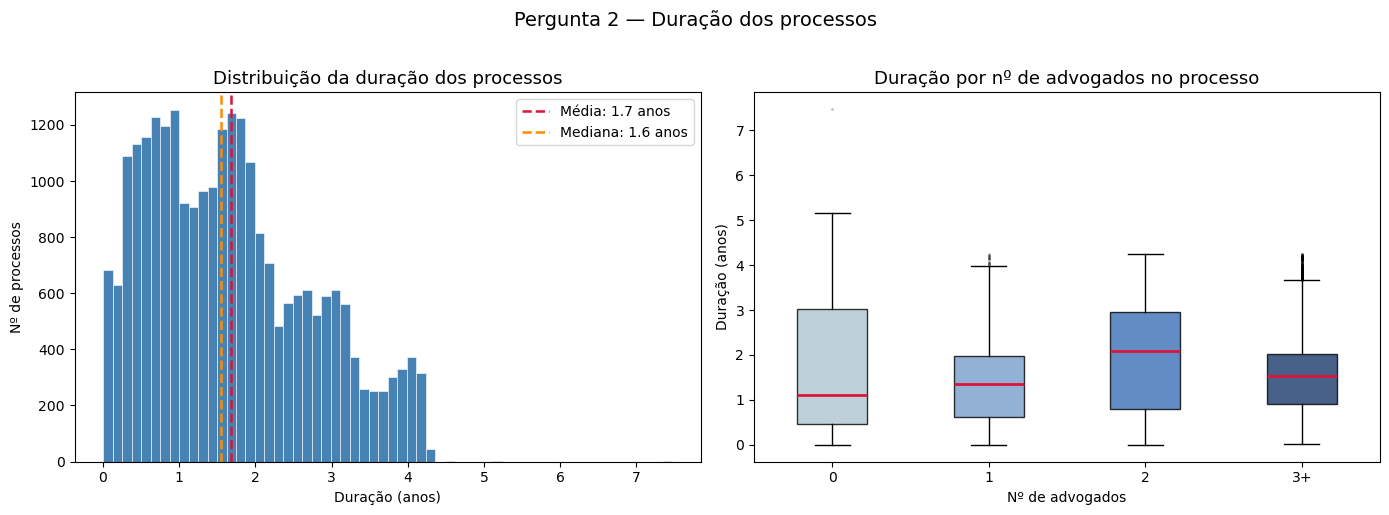

In [31]:
# Distribuição da duração dos processo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

duracao_anos = df_p2['duracao_dias'] / 365
media   = duracao_anos.mean()
mediana = duracao_anos.median()

# Histograma
axes[0].hist(duracao_anos, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(media,   color='crimson',    linestyle='--', lw=1.8, label=f'Média: {media:.1f} anos')
axes[0].axvline(mediana, color='darkorange', linestyle='--', lw=1.8, label=f'Mediana: {mediana:.1f} anos')
axes[0].set_title('Distribuição da duração dos processos', fontsize=13)
axes[0].set_xlabel('Duração (anos)')
axes[0].set_ylabel('Nº de processos')
axes[0].legend()

# Boxplot duração × faixa de advogados
ordem  = ['0', '1', '2', '3+']
cores  = ['#aec6cf', '#779ecb', '#3b6fb6', '#1a3a6b']
dados  = [df_p2[df_p2['faixa_advogados'] == f]['duracao_dias'].values / 365 for f in ordem]
bp = axes[1].boxplot(
    dados, labels=ordem, patch_artist=True,
    medianprops=dict(color='crimson', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.25),
    whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor); patch.set_alpha(0.8)
axes[1].set_title('Duração por nº de advogados no processo', fontsize=13)
axes[1].set_xlabel('Nº de advogados')
axes[1].set_ylabel('Duração (anos)')

plt.suptitle('Pergunta 2 — Duração dos processos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


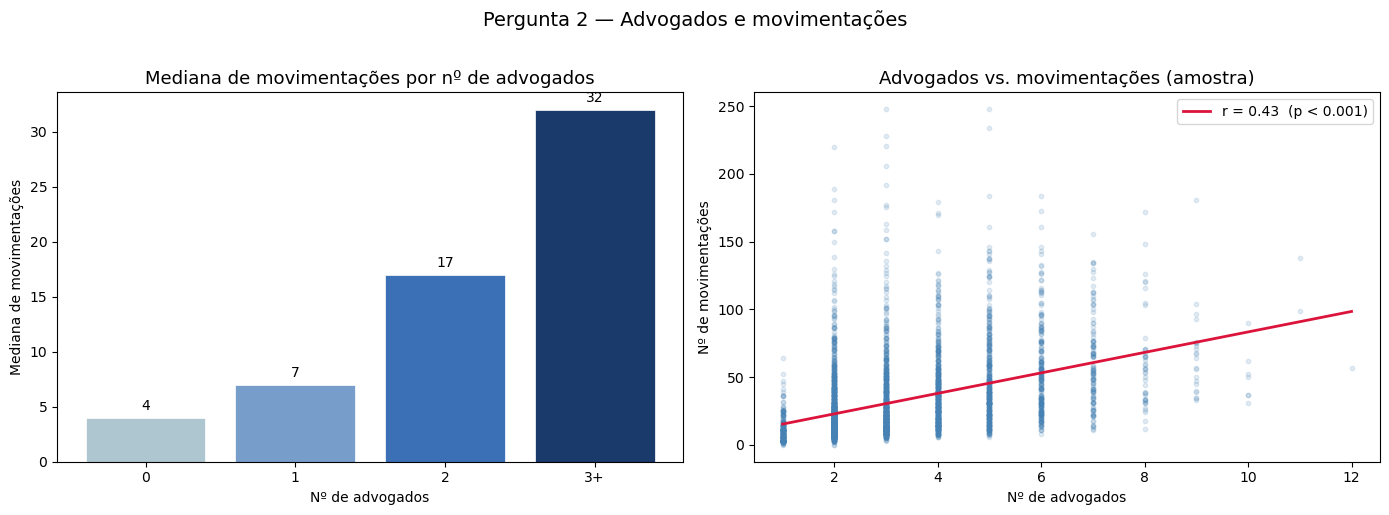

In [32]:
# Advogados × Movimentações 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mediana de movimentações por faixa
cores = ['#aec6cf', '#779ecb', '#3b6fb6', '#1a3a6b']
resumo = (
    df_p2.groupby('faixa_advogados')['qtd_movimentacoes']
    .median()
    .loc[['0', '1', '2', '3+']]
    .reset_index()
    .rename(columns={'qtd_movimentacoes': 'mediana_mov'})
)
bars = axes[0].bar(resumo['faixa_advogados'], resumo['mediana_mov'],
                   color=cores, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, resumo['mediana_mov']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Mediana de movimentações por nº de advogados', fontsize=13)
axes[0].set_xlabel('Nº de advogados')
axes[0].set_ylabel('Mediana de movimentações')

# Scatter com linha de tendência
amostra = df_p2[df_p2['qtd_advogados'] > 0].sample(min(4000, len(df_p2)), random_state=42)
axes[1].scatter(amostra['qtd_advogados'], amostra['qtd_movimentacoes'],
                alpha=0.15, s=10, color='steelblue')
slope, intercept, r, p_val, _ = stats.linregress(
    amostra['qtd_advogados'], amostra['qtd_movimentacoes']
)
xr = np.array([1, amostra['qtd_advogados'].max()])
p_label = '< 0.001' if p_val < 0.001 else f'= {p_val:.3f}'
axes[1].plot(xr, slope * xr + intercept, color='crimson', lw=2,
             label=f'r = {r:.2f}  (p {p_label})')
axes[1].set_title('Advogados vs. movimentações (amostra)', fontsize=13)
axes[1].set_xlabel('Nº de advogados')
axes[1].set_ylabel('Nº de movimentações')
axes[1].legend()

plt.suptitle('Pergunta 2 — Advogados e movimentações', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Conclusões — Pergunta 2

**Duração média dos processos**
- A duração **média** é consideravelmente maior que a **mediana**, evidenciando assimetria à direita: a maior parte dos processos se resolve em poucos anos, mas uma cauda de casos muito longos eleva a média.
- Processos com **mais advogados** apresentam medianas de duração crescentes, o que é esperado: casos mais complexos (mais partes, mais recursos) tanto atraem mais representação legal quanto se arrastam por mais tempo.

**Advogados e movimentações**
- Há uma **correlação positiva** clara entre o número de advogados e a quantidade de movimentações: processos com 3+ advogados registram significativamente mais eventos do que processos com 1.
- O coeficiente de Pearson (`r`) e o p-valor confirmam que a relação é **estatisticamente significativa**.
- Uma interpretação plausível: processos complexos (mais crimes, mais réus, mais recursos) geram mais movimentações *e*, por isso mesmo, demandam mais advogados — a causalidade provavelmente vai nos dois sentidos.


## Pergunta 3

- 3- Os casos que nunca foram encerrados ou duraram mais de 1 ano são do mesmo juiz? Os crimes desses casos são semelhantes ou os advogados associados são os mesmos?

A resposta dessa pergunta está relacionada com as tabelas de **df_attorneys**, **df_calendar_jud** e **df_charge_disp**

### Pré-Processamento

In [33]:
df_attorneys.info()

<class 'pandas.DataFrame'>
RangeIndex: 72289 entries, 0 to 72288
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             72289 non-null  int64
 1   case_number    72289 non-null  str  
 2   name           72289 non-null  str  
 3   attorney_type  72289 non-null  str  
dtypes: int64(1), str(3)
memory usage: 5.5 MB


In [34]:
df_calendar_jud.info()

<class 'pandas.DataFrame'>
RangeIndex: 318993 entries, 0 to 318992
Data columns (total 27 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                318993 non-null  int64  
 1   case_number                       318993 non-null  str    
 2   court_date                        318993 non-null  str    
 3   hearing_type                      318993 non-null  str    
 4   location                          318993 non-null  str    
 5   dept                              318993 non-null  str    
 6   calendar_department               318993 non-null  str    
 7   calendar_date                     318993 non-null  str    
 8   assigned_judge                    318318 non-null  str    
 9   assigned_judges                   318318 non-null  str    
 10  assigned_judges_raw               318318 non-null  str    
 11  assigned_judge_canonical_key      318318 non-null  str    
 12 

In [35]:
df_charge_disp.info()

<class 'pandas.DataFrame'>
RangeIndex: 44029 entries, 0 to 44028
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   sfsc_charge_id                  44029 non-null  int64  
 1   anon_case_id                    44029 non-null  str    
 2   case_number                     44029 non-null  str    
 3   charge_count                    44015 non-null  float64
 4   filed_date                      44029 non-null  str    
 5   statute_number                  44029 non-null  str    
 6   normalized_statute              44029 non-null  str    
 7   normalized_charge_type_initial  44029 non-null  str    
 8   normalized_charge_modifier      44029 non-null  str    
 9   statute_description             44029 non-null  str    
 10  charge_type_initial             44029 non-null  str    
 11  charge_type_dispo               28093 non-null  str    
 12  charge_allegations              63 non-null

In [36]:
# Analisando o dataframe de calendário com juízes, percebemos muitos valores nulos na coluna 'assigned_judge_canonical_name'. Decidimos remover as linhas onde essa coluna é nula.
df_calendar_jud = df_calendar_jud[~df_calendar_jud['assigned_judge_canonical_name'].isna()]

In [37]:
df_calendar_jud['calendar_date'] = pd.to_datetime(
    df_calendar_jud['calendar_date']
)

# Para cada caso, queremos obter a data de início e os juízes envolvidos.
case_summary = (
    df_calendar_jud
    .groupby('case_number')
    .agg(
        start_date=('calendar_date', 'min'),
        judge=('assigned_judge_canonical_name',
               lambda x: ', '.join(sorted(set(x.dropna()))))
    )
    .reset_index()
)

In [38]:
# Agregando os advogados envolvidos em cada caso.
attorneys = (
    df_attorneys
    .groupby('case_number')
    .agg(
        attorneys=('name',
                   lambda x: ', '.join(sorted(set(x))))
    )
    .reset_index()
)

In [39]:
df_charge_disp['dispo_date'] = pd.to_datetime(
    df_charge_disp['dispo_date']
)


# Agregando os tipos de crime envolvidos em cada caso, data da decisão e informação de caso fechado.
charges = (
    df_charge_disp
    .groupby("case_number")
    .agg(
        last_dispo_date=('dispo_date', 'max'),
        crime_types=(
            "statute_description",
            lambda x: ", ".join(sorted(set(x.dropna())))
        ),
        closed_case=(
            'dispo_type',
            lambda x: x.notna().all()
        )
    )
    .reset_index()
)

In [40]:
# Unindo as informações de resumo do caso, advogados e tipos de crime em um único dataframe.
df_result = (
    case_summary
    .merge(attorneys, on="case_number", how="left")
    .merge(charges, on="case_number", how="left")
)

In [41]:
# Verificando quantos casos possuem dados nulos.
df_result.isna().sum()

case_number            0
start_date             0
judge                  0
attorneys           1502
last_dispo_date    16228
crime_types        10408
closed_case        10408
dtype: int64

In [42]:
df_result['case_duration'] = (
    df_result['last_dispo_date'] - df_result['start_date']
).dt.days

# Removendo casos que não possuem informações de advogados ou tipos de crime, as demais colunas podem estar relacionadas aos casos em aberto.
df_result = df_result.dropna(subset=['attorneys', 'crime_types'])

# Mantendo os casos com mais de um ano de duração ou caso fechado.
df_result = df_result[(df_result['case_duration'] > 365) | (df_result['closed_case'] == True)]

In [43]:
df_result

,case_number,start_date,judge,attorneys,last_dispo_date,crime_types,closed_case,case_duration
599,CRI22006124,2022-07-25,"Brian L. Ferrall, Gail Dekreon, Vedica Puri, V...","MIKE SILVEIRA, San Francisco District Attorney...",2024-04-08,"DRIVING UNDER THE INFLUENCE OF ALCOHOL, DRIVIN...",True,623.0
614,CRI22006251,2022-07-01,"A. Marisa Chun, Charles Crompton, Christopher ...","San Francisco District Attorney's Office, San ...",2022-10-21,BATTERY UPON AN OFFICER AND EMERGENCY PERSONNE...,True,112.0
616,CRI22006284,2022-07-01,"Charles Crompton, Christine Van Aken, Loretta ...","San Francisco District Attorney's Office, San ...",2022-07-18,"KILLING, MAIMING OR ABUSING ANIMALS",True,17.0
619,CRI22006325,2022-07-05,"A. Marisa Chun, Loretta M. Giorgi","Brittney Delgado, NEIL HALLINAN, San Francisco...",2023-06-28,"SEXUAL BATTERY BY RESTRAINT, SEXUAL PENETRATIO...",True,358.0
620,CRI22006326,2022-07-05,"Carolyn Gold, Gail Dekreon, Michael Rhoads, Ve...","San Francisco District Attorney's Office, San ...",2024-08-05,"DOMESTIC VIOLENCE, FALSE IMPRISONMENT",True,762.0
...,...,...,...,...,...,...,...,...
23132,CRI26402169,2026-02-13,Brian J. Stretch,"James Robbins, Liliana Garcia",2026-02-13,LOITERING TO COMMIT CONTROLLED SUBSTANCE OFFEN...,True,0.0
23154,CRI26403536,2026-03-02,"Brian J. Stretch, Visiting Judge","Anjuli Webb, Michael Foley",2026-04-02,UNAUTHORIZED LODGING,True,31.0
23155,CRI26403538,2026-03-02,"Brian J. Stretch, Maria E. Evangelista","GINA KUNG, James Filling",NaT,"POSSESSION OF GRAFFITI INSTRUMENTS, RESISTING,...",True,NaN
23186,CRI26404807,2026-03-23,"Brian J. Stretch, Maria E. Evangelista",GINA KUNG,NaT,CARRYING A SWITCHBLADE KNIFE,True,NaN


### Análise Exploratória dos Dados

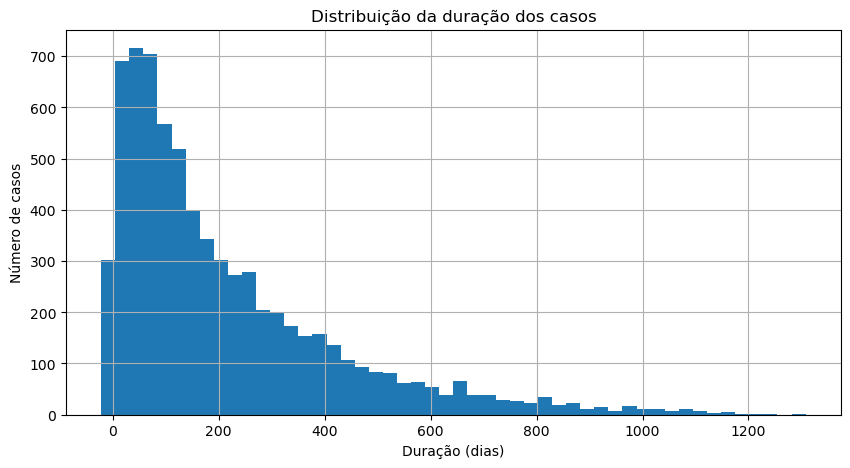

In [44]:
plt.figure(figsize=(10,5))
df_result['case_duration'].dropna().hist(bins=50)
plt.xlabel('Duração (dias)')
plt.ylabel('Número de casos')
plt.title('Distribuição da duração dos casos')
plt.show()

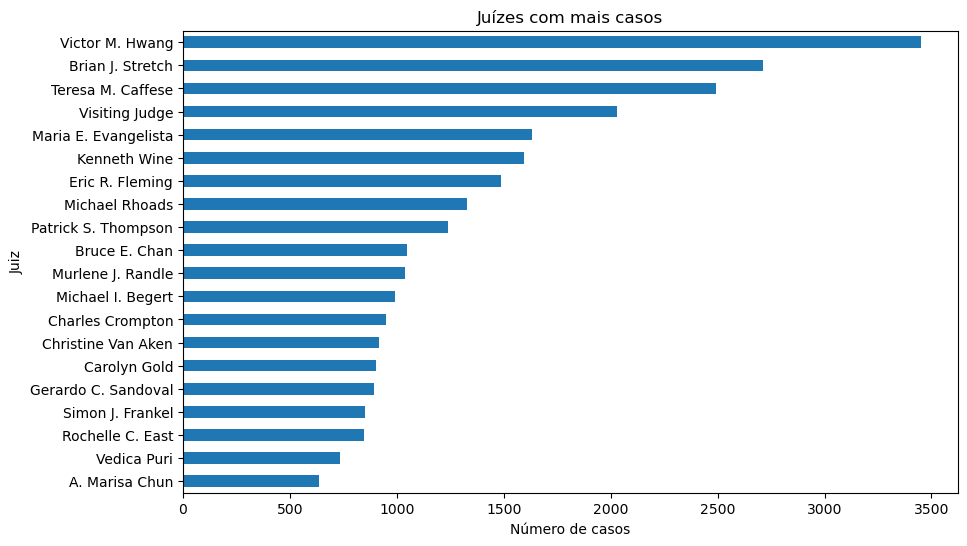

In [45]:
judge_df = (
    df_result[['case_number', 'judge']]
    .copy()
)

judge_df['judge'] = judge_df['judge'].str.split(',')

judge_df = judge_df.explode('judge')

judge_df['judge'] = judge_df['judge'].str.strip()

top_judges = judge_df['judge'].value_counts().head(20)

plt.figure(figsize=(10,6))
top_judges.sort_values().plot(kind='barh')
plt.title('Juízes com mais casos')
plt.xlabel('Número de casos')
plt.ylabel('Juiz')
plt.show()

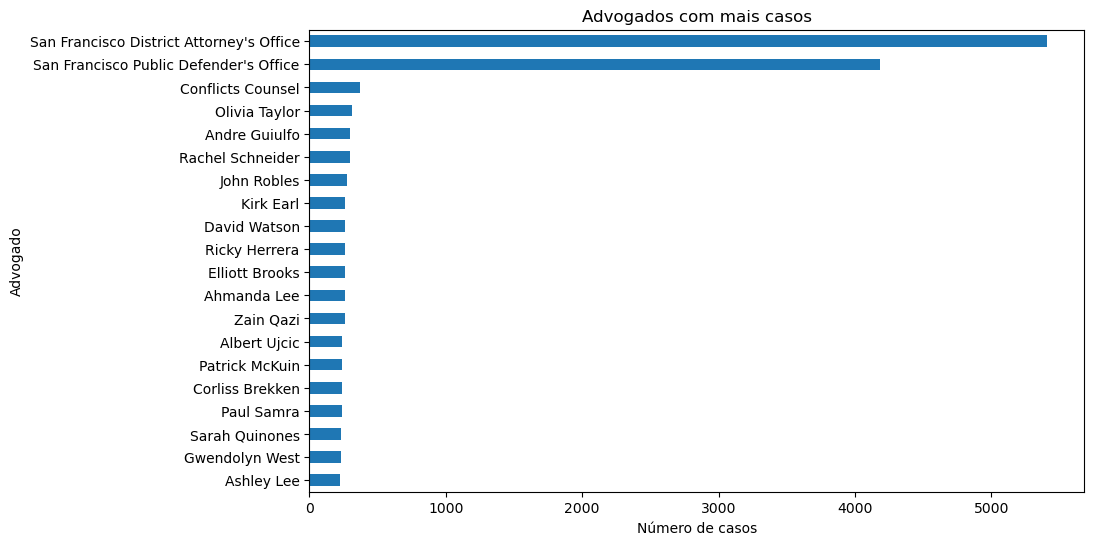

In [46]:
attorney_df = (
    df_result[['case_number', 'attorneys']]
    .copy()
)

attorney_df['attorneys'] = attorney_df['attorneys'].str.split(',')
attorney_df = attorney_df.explode('attorneys')
attorney_df['attorneys'] = attorney_df['attorneys'].str.strip()

top_attorneys = attorney_df['attorneys'].value_counts().head(20)

plt.figure(figsize=(10,6))
top_attorneys.sort_values().plot(kind='barh')
plt.title('Advogados com mais casos')
plt.xlabel('Número de casos')
plt.ylabel('Advogado')
plt.show()

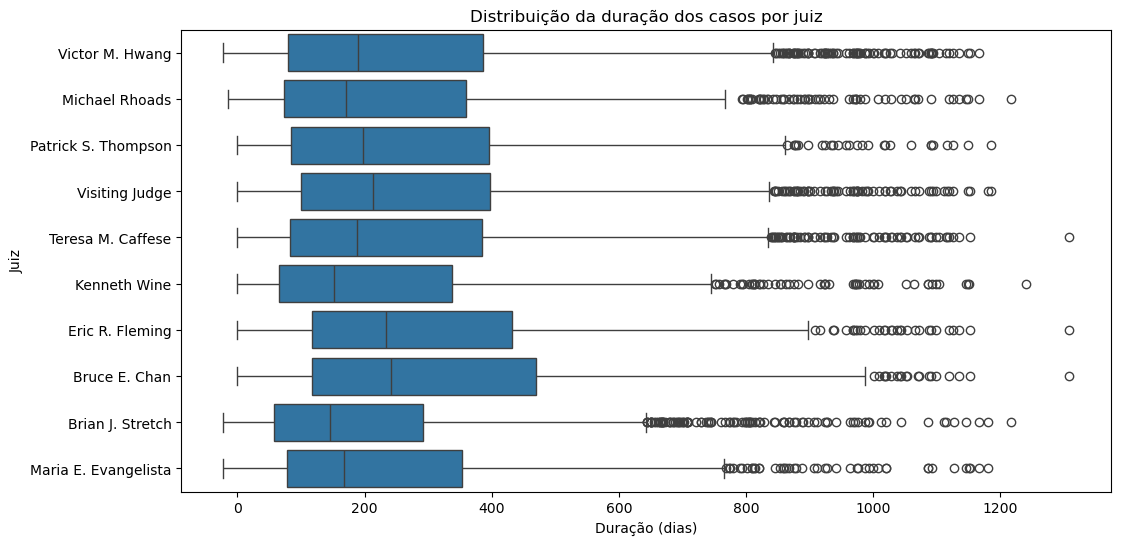

In [47]:
top_judges = (
    judge_df['judge']
    .value_counts()
    .head(10)
    .index
)

box_df = judge_df.merge(
    df_result[['case_number', 'case_duration']],
    on='case_number'
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=box_df[box_df['judge'].isin(top_judges)],
    x='case_duration',
    y='judge'
)

plt.title('Distribuição da duração dos casos por juiz')
plt.xlabel('Duração (dias)')
plt.ylabel('Juiz')
plt.show()

<Axes: ylabel='crime_types'>

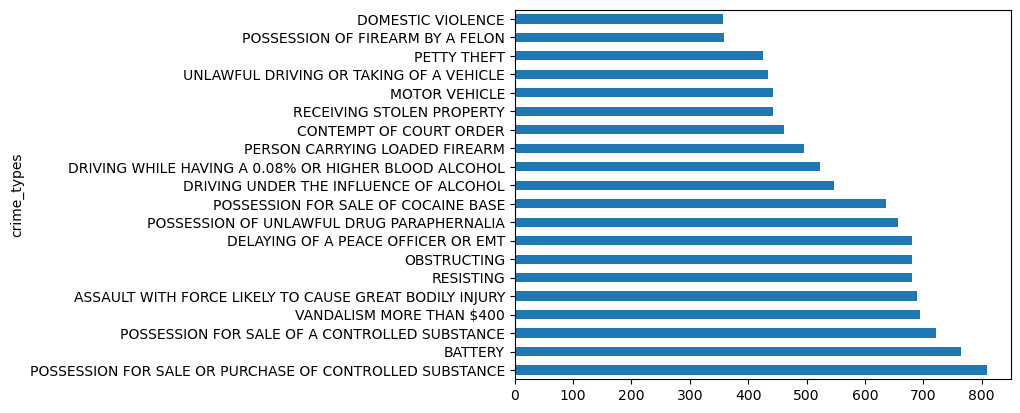

In [48]:
crime_df = (
    df_result[['case_number', 'crime_types']]
    .dropna()
)

crime_df['crime_types'] = crime_df['crime_types'].str.split(',')

crime_df = crime_df.explode('crime_types')

crime_df['crime_types'] = crime_df['crime_types'].str.strip()

crime_df['crime_types'].value_counts().head(20).plot.barh()

In [49]:
df_result.nlargest(
    20,
    'case_duration'
)[[
    'case_number',
    'judge',
    'case_duration',
    'crime_types',
    'attorneys'
]]

,case_number,judge,case_duration,crime_types,attorneys
837,CRI22009486,"A. Marisa Chun, Bruce E. Chan, Christopher C. ...",1308.0,"POSSESSION FOR SALE OF A CONTROLLED SUBSTANCE,...","Andre Guiulfo, Axell Hernandez, Dennis Chow, S..."
1096,CRI22012923,"Charles Crompton, Christine Van Aken, Kenneth ...",1240.0,"ASSAULT WITH A DEADLY WEAPON NOT A FIREARM, AS...","San Francisco District Attorney's Office, San ..."
1140,CRI22013363,"Brian J. Stretch, Carolyn Gold, Michael Rhoads",1217.0,"INFLICTING INJURY ON ELDER OR DEPENDENT ADULT,...","Ahmanda Lee, Austin Weis, Charlotte Miller, Je..."
1243,CRI22014687,"Christine Van Aken, Michael McNaughton, Murlen...",1185.0,"POSSESSION OF A CONTROLLED SUBSTANCE, RESISTIN...","San Francisco District Attorney's Office, San ..."
1839,CRI23001199,"Brian J. Stretch, Brian L. Ferrall, Maria E. E...",1181.0,"BATTERY, BATTERY UPON AN OFFICER AND EMERGENCY...","Michael Foley, Owen Nelson, San Francisco Dist..."
722,CRI22007858,"Brian J. Stretch, Gail Dekreon, Maria E. Evang...",1167.0,"FELON POSS/ETC STUN GUN, POSSESSION, USE OF TE...","Austin Weis, David Watson, San Francisco Distr..."
1841,CRI23001201,"A. Marisa Chun, Bruce E. Chan, Christine Van A...",1152.0,"RECEIVING STOLEN PROPERTY, MOTOR VEHICLE","Safa Lele, San Francisco District Attorney's O..."
1417,CRI22409564,"A. Marisa Chun, Kenneth Wine, Maria E. Evangel...",1151.0,ASSAULT UPON A PEACE OFFICER WITH A DEADLY WEA...,"Gwendolyn West, MICHAEL GAINES, San Francisco ..."
1147,CRI22013409,"Christine Van Aken, Murlene J. Randle, Patrick...",1150.0,"GRAND THEFT, POSSESSION OF CONTROLLED SUBSTANC...","Katharine Bryant, Ricky Herrera, San Francisco..."
889,CRI22010202,"Adrienne L. Rogers, Brian L. Ferrall, Carolyn ...",1149.0,"HAVING A CONCEALED FIREARM IN A VEHICLE, PERSO...","Aaron Johnson, Andre Guiulfo, CHERYL RICH, Ros..."


### Resposta da Pergunta 3

- A análise dos juízes mostrou que os casos longos ou sem encerramento não estão concentrados em um único juiz. Embora alguns juízes apareçam com maior frequência, especialmente Brian J. Stretch, Maria E. Evangelista e Victor M. Hwang, os boxplots de duração indicaram que casos extremamente longos estão distribuídos entre diferentes juízes. Isso sugere que a demora está mais relacionada à complexidade dos processos do que à atuação de um juiz específico.
- Os casos que permaneceram ativos por mais de um ano ou sem encerramento registrado apresentam uma concentração em alguns tipos de crime recorrentes, principalmente vandalismo, agressões, tráfico ou posse para venda de drogas, receptação de veículos roubados, furtos e infrações relacionadas à direção sob efeito de álcool ou drogas. Esse padrão sugere que os processos mais demorados compartilham características semelhantes e tendem a exigir maior acompanhamento judicial.
- Não foram encontradas evidências de forte concentração em advogados específicos. Embora alguns profissionais apareçam repetidamente nos casos analisados, as frequências são relativamente próximas entre si. Os nomes mais comuns pertencem principalmente ao San Francisco District Attorney's Office e ao San Francisco Public Defender's Office, o que era esperado devido ao papel institucional dessas organizações na maioria dos processos criminais. Portanto, a longa duração dos casos não parece estar associada a advogados específicos.

## Pergunta 5
- 5- Análise de Sazonalidade no Tribunal Criminal de São Francisco. Existe algum padrão de aumento ou queda no número de processos criminais dependendo do mês do ano?

In [50]:
df_cases.head()

,case_number,case_id,defendant_name,filed_date,scraped_at,duracao_dias
0,CRI25000001,4161165,CHANTAIL L MYLES,2025-01-02,2026-03-20 22:52:53.372069,442.0
1,CRI25000005,4161163,DAJCHA JNALASHAY LANDERS,2025-02-28,2026-03-20 22:57:56.233258,385.0
2,CRI25000007,4161183,JOHN MARSHALL THORNTON,NaT,2026-03-20 22:58:17.392932,NaN
3,CRI25000008,4161184,CATHERINE MICHELLE WHITE,2025-01-06,2026-03-20 22:58:43.779784,438.0
4,CRI25000009,4161185,IDRISSA O SOW,NaT,2026-03-20 22:58:50.308604,NaN


In [51]:
df_cases['filed_date'] = pd.to_datetime(df_cases['filed_date'], errors='coerce')

linhas_antes = len(df_cases)
df_cases = df_cases.dropna(subset=['filed_date'])
linhas_depois = len(df_cases)
print(f"Linhas sem data removidas: {linhas_antes - linhas_depois}")

df_cases['mes_abertura'] = df_cases['filed_date'].dt.month
df_cases['ano_abertura'] = df_cases['filed_date'].dt.year

df_cases[['case_number', 'filed_date', 'mes_abertura', 'ano_abertura']].head()

Linhas sem data removidas: 51984


,case_number,filed_date,mes_abertura,ano_abertura
0,CRI25000001,2025-01-02,1,2025
1,CRI25000005,2025-02-28,2,2025
3,CRI25000008,2025-01-06,1,2025
7,CRI25000012,2025-01-03,1,2025
9,CRI25000014,2025-01-03,1,2025


In [52]:
casos_por_mes_total = df_cases.groupby('mes_abertura')['case_number'].count()

casos_por_ano_mes = df_cases.groupby(['ano_abertura', 'mes_abertura'])['case_number'].count().reset_index()
casos_por_ano_mes.rename(columns={'case_number': 'total_casos'}, inplace=True)

anos_completos = casos_por_ano_mes['ano_abertura'].value_counts()
anos_validos = anos_completos[anos_completos == 12].index
casos_por_ano_mes = casos_por_ano_mes[casos_por_ano_mes['ano_abertura'].isin(anos_validos)]

print("Agregações concluídas.")

Agregações concluídas.


/tmp/ipykernel_12244/879164036.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(dados_boxplot, labels=meses_labels, patch_artist=True, boxprops=dict(facecolor='lightgreen'))


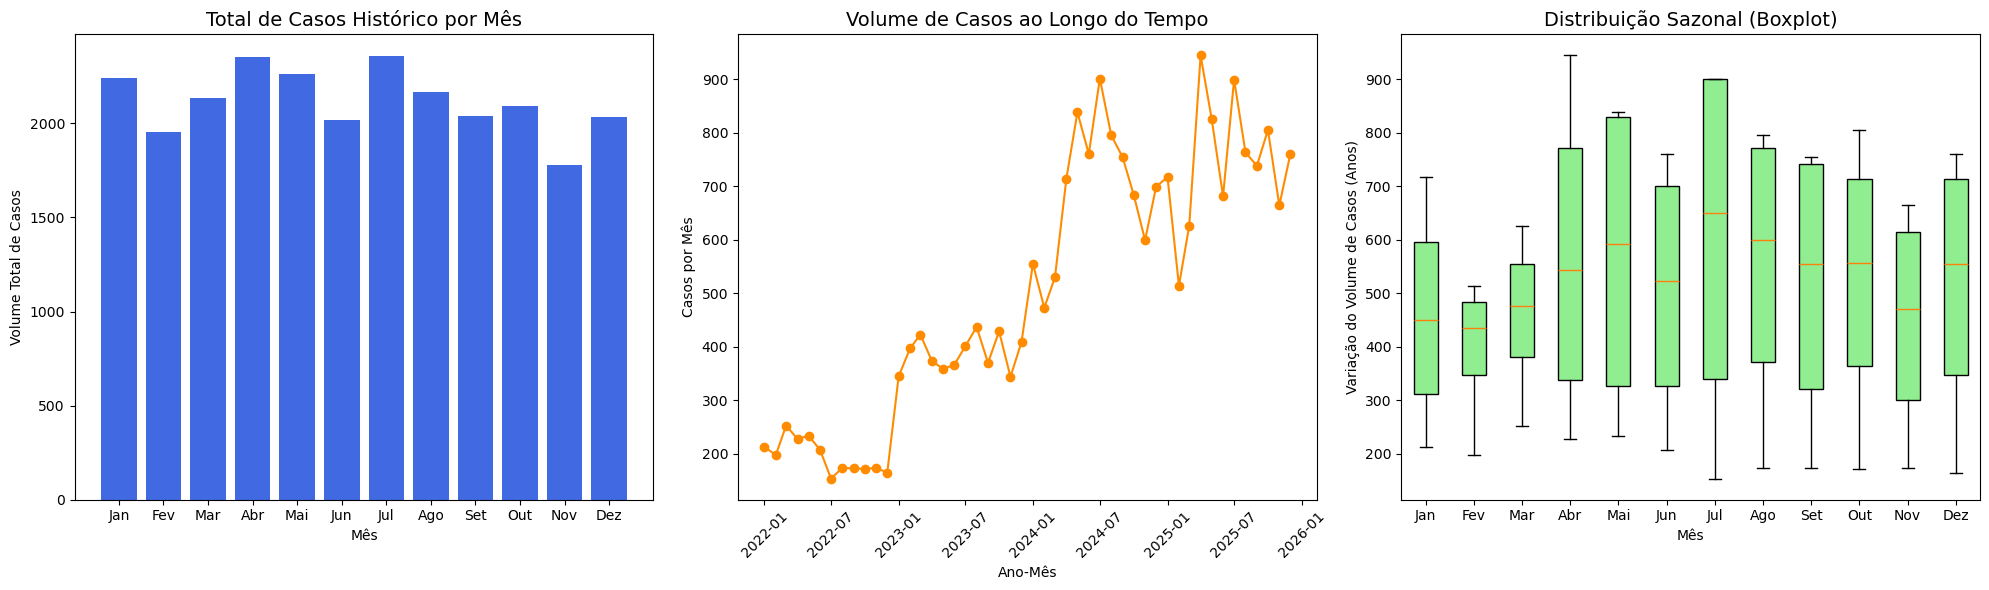

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

axes[0].bar(casos_por_mes_total.index, casos_por_mes_total.values, color='royalblue')
axes[0].set_title('Total de Casos Histórico por Mês', fontsize=14)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Volume Total de Casos')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses_labels)

casos_por_ano_mes['data_plot'] = pd.to_datetime(
    casos_por_ano_mes['ano_abertura'].astype(str) + '-' + casos_por_ano_mes['mes_abertura'].astype(str) + '-01'
)
casos_por_ano_mes = casos_por_ano_mes.sort_values('data_plot')

axes[1].plot(casos_por_ano_mes['data_plot'], casos_por_ano_mes['total_casos'], marker='o', color='darkorange')
axes[1].set_title('Volume de Casos ao Longo do Tempo', fontsize=14)
axes[1].set_xlabel('Ano-Mês')
axes[1].set_ylabel('Casos por Mês')
axes[1].tick_params(axis='x', rotation=45)

dados_boxplot = [casos_por_ano_mes[casos_por_ano_mes['mes_abertura'] == i]['total_casos'].values for i in range(1, 13)]

axes[2].boxplot(dados_boxplot, labels=meses_labels, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].set_title('Distribuição Sazonal (Boxplot)', fontsize=14)
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('Variação do Volume de Casos (Anos)')

plt.tight_layout()
plt.show()

- Os meses de Fevereiro e Novembro apresentam os menores volumes totais (Gráfico 1) e também as menores variâncias e medianas no Boxplot.
- Meses como Abril e Julho concentram o maior volume histórico, porém, o Boxplot indica que o comportamento não é estável todos os anos; os números foram puxados para cima por eventos atípicos recentes.
- O gráfico de linhas (Gráfico 2) mostra uma explosão estrutural. O volume sai de um patamar baixo e estável em 2022 e inflama violentamente a partir do final de 2023, mantendo extrema volatilidade ao longo de 2024 e 2025.